# Quick Start Guide to LangChain

#### Ignoring the Warning

In [ ]:
import warnings
warnings.filterwarnings("ignore", message='''Direct use of automatic function calling (AFC) in Models.generate_content is not recommended. 
Instead, we recommend to use AFC in Chat.send_message. 
Similarly, direct use of AFC in Models.generate_content_stream is not recommended. 
Instead, we recommend to use AFC in Chat.send_message_stream.''')

Google recently updated their SDK to recommend using a different method (Chat.send_message) for agents that use tools or function calling. Because LangChain's internal code hasn't fully migrated to this new method yet, Google's SDK prints this warning.

#### 1. Direct Chat with LLM

In [ ]:
from dotenv import load_dotenv

load_dotenv()

from langchain.chat_models import init_chat_model

# you must install langchain-google-vertexai
model = init_chat_model(model="gemini-3.6-flash")

response = model.invoke("What's the capital of the Pakistan?")

print(response)

<i> Set the credentials on Google Cloud and Run the above code.</i>

#### 2. Alternative Way

In [ ]:
from dotenv import load_dotenv

load_dotenv()

from langchain_google_genai import ChatGoogleGenerativeAI

model = ChatGoogleGenerativeAI(model="gemini-3.6-flash")

response = model.invoke("What's the capital of the Pakistan")


Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.


In [19]:
print(response.content[-1]['text'])

The capital of Pakistan is **Islamabad**.


#### 3. Customizing model

In [20]:
from dotenv import load_dotenv

load_dotenv()

from langchain_google_genai import ChatGoogleGenerativeAI

model = ChatGoogleGenerativeAI(model="gemini-3.6-flash", temperature=1.0)

response = model.invoke("What's the capital of the Pakistan")

print(response.content[-1]['text'])

Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.
c:\Users\kamra\OneDrive\Desktop\corvit-agentic-ai\.venv\Lib\site-packages\langchain_google_genai\chat_models.py:3908: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


The capital of Pakistan is **Islamabad**.


### 4. Building Agent

In [22]:
from langchain.agents import create_agent
from dotenv import load_dotenv

load_dotenv()

# Install langchain-google-genai 
agent = create_agent(model="google_genai:gemini-3.6-flash")


result = agent.invoke({"messages": [{"role": "user", "content": "Give me th names of 5 top trendiong AI topics in 2024."}]})

print(result["messages"][-1].content)

# Extract the AI message (the last message in the list)
ai_message = result["messages"][-1]

# Extract the actual text from the first content block
response_text = ai_message.content[0]["text"]

print(response_text)

Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.


[{'type': 'text', 'text': 'Here are 5 of the top trending AI topics in 2024:\n\n1. **Multimodal AI & Generative Video**\n   * **What it is:** AI models that can process and generate multiple types of media simultaneously—text, audio, images, and video. \n   * **Why it’s trending in 2024:** Breakthroughs like OpenAI’s **Sora** (text-to-video) and **GPT-4o** (native real-time voice, vision, and text) have moved AI far beyond simple text chatbots into realistic real-time multimedia interaction.\n\n2. **Autonomous AI Agents & Agentic Workflows**\n   * **What it is:** Instead of just answering questions, AI systems are now designed to reason, plan, and execute multi-step tasks autonomously with minimal human oversight.\n   * **Why it’s trending in 2024:** Tools like software development agents (e.g., Devin) and multi-agent frameworks allow AI to handle complex, end-to-end workflows like coding an entire app, conducting market research, or managing supply chains.\n\n3. **Small Language Model

##### pprint

In [23]:
from pprint import pprint

pprint(result)

{'messages': [HumanMessage(content='Give me th names of 5 top trendiong AI topics in 2024.', additional_kwargs={}, response_metadata={}, id='eed7b43e-9404-49b5-8ae3-77a101779796'),
              AIMessage(content=[{'type': 'text', 'text': 'Here are 5 of the top trending AI topics in 2024:\n\n1. **Multimodal AI & Generative Video**\n   * **What it is:** AI models that can process and generate multiple types of media simultaneously—text, audio, images, and video. \n   * **Why it’s trending in 2024:** Breakthroughs like OpenAI’s **Sora** (text-to-video) and **GPT-4o** (native real-time voice, vision, and text) have moved AI far beyond simple text chatbots into realistic real-time multimedia interaction.\n\n2. **Autonomous AI Agents & Agentic Workflows**\n   * **What it is:** Instead of just answering questions, AI systems are now designed to reason, plan, and execute multi-step tasks autonomously with minimal human oversight.\n   * **Why it’s trending in 2024:** Tools like software develo

### 5. Human Message and AI Message

In [28]:
from langchain.messages import HumanMessage

response = agent.invoke(
    {"messages": [HumanMessage(content="My name is Kamran. What is your name?")]}
)

In [29]:
pprint(response)

{'messages': [HumanMessage(content='My name is Kamran. What is your name?', additional_kwargs={}, response_metadata={}, id='6ea9f56d-c5cd-4edd-a08f-5555ab98eb0b'),
              AIMessage(content=[{'type': 'text', 'text': 'Hello Kamran! I am Gemini, a large language model built by Google. How can I help you today?', 'extras': {'signature': 'EvYECvMEAWkUfRM/YV8kcBguwormq9Lf6ODqZQIZFdU5ZTxVrIfTndbBptNX2A5KJ4Qn+DYz2cY6cnDf5p9Eiaz+zmgeTncfnjkZrQqa9j2WaTWfZwHWB/C6hYqJAiWU6QeF6ne6xTcIAmXgJMWRY/3yFZVInqZcw6RuLnEesrvVnmBHRLX/N2IfXymbBVp5AQcNS+QZ783pIBNC8oWGt5aePGYYR9avFLEUIUnw4R3anYUaEEDr5LdQfTsLlcRqvzcb5liyrj+QuLuhzEsKY7Ge8WX8nddfPeJKQ7amNCRAa3d/WT7vrIF7xg2U3XiD6g/6+8yMRA1Ui9KIx2WfrB9vDBdgoeCgsY+AY6/GD9eNrqU4LLbX28E1tsvc75EWmDZelwfWWe9hbwO9M79UrUvzf7Uo9rD7OgkCqQAHlD9L0aVmic8dC5aZ+g6ZSxCWAF+rzjiZZ9Dh6TKV1WqaYLpL8VwFH/Ftfv/k1HwmA7n005FSSQi4jJoZp1jkG4juvjLCE0WwYERwFB/1RyjCT5nX2Mgcc438Fr1/SZny6teeOnx9qrx2I8UWzyLd1L6Rb6/Lf0b30XAQZF7npSS2jmqiMRme+LcWE4YCc5i9utOeOrF6KRUBGwZh7c5C+P3h0YcrdE7uOGQvKtdsz

### 6. LLMs are Stateless 

In [31]:
response = agent.invoke(
    {"messages": [HumanMessage(content="What is my name?")]}
)

pprint(response)

{'messages': [HumanMessage(content='What is my name?', additional_kwargs={}, response_metadata={}, id='36dc0547-236a-4d5e-bef8-98157475843f'),
              AIMessage(content=[{'type': 'text', 'text': "I don't know your name yet! Since I don't have access to your personal information, you'll have to tell me. What should I call you?", 'extras': {'signature': 'EsYGCsMGAWkUfRNmb3yRtgy2Q4yQYHREmjHoL9nojARH6yWgbJXUbs3n5IyDaJrl0p5llpaEOLZ/XFSzU7OgqabbAoGDnBMjjVXQewbuWfpejho1YoyOgnk2hPzc9gfysQJCTv4LBQwLJC60cmZsGxHCPyPbeC61rzgOSfphExcLXuHTTcU/bRKOsl1kg5ZCKP0snMuqJ6VyWPZdTMgbcfRFHa8vg97nMP9q5h8+sCOOpWsiHqzaq5ACJkEv/z64b0WAHYU1+0sANRAsCxDaVoaziQBb6wxc4Lg9MrU+dKumlrsfY1KJGc2aY0wz8yooLRkm9JYIe8s4aRrYTkj9iMrL+WometK3/G3Gs9STsO+swT/qbASuJ5cd3lPOTz6os/ea76e8CjZFNVuWH6hiW1Xwwv7wzDe3IJYOA6ShNXzxp5U7h/d8l9ewn2ZTDjGrmVZCiZTjdsgkYZpfJEB8UwokLUC2MtgG1NY/z5PwI2VoEJm7RYk+5jKWgQ/58E3+M7tQQOVjUOPfOKcM6tceYfodTkB1+B3bOuEjdCJvZe2reeCdbHFX3rWSnOtOonTJ/HCCgo29NW2mnpGRcMld0/v5Oyg8Hu/9G/XGABtwwNb+84b4cwqJ6jfYf7RVPWE

#### Solution

![Screenshot 2026-09-18 144452.png](<attachment:Screenshot 2026-09-18 144452.png>)
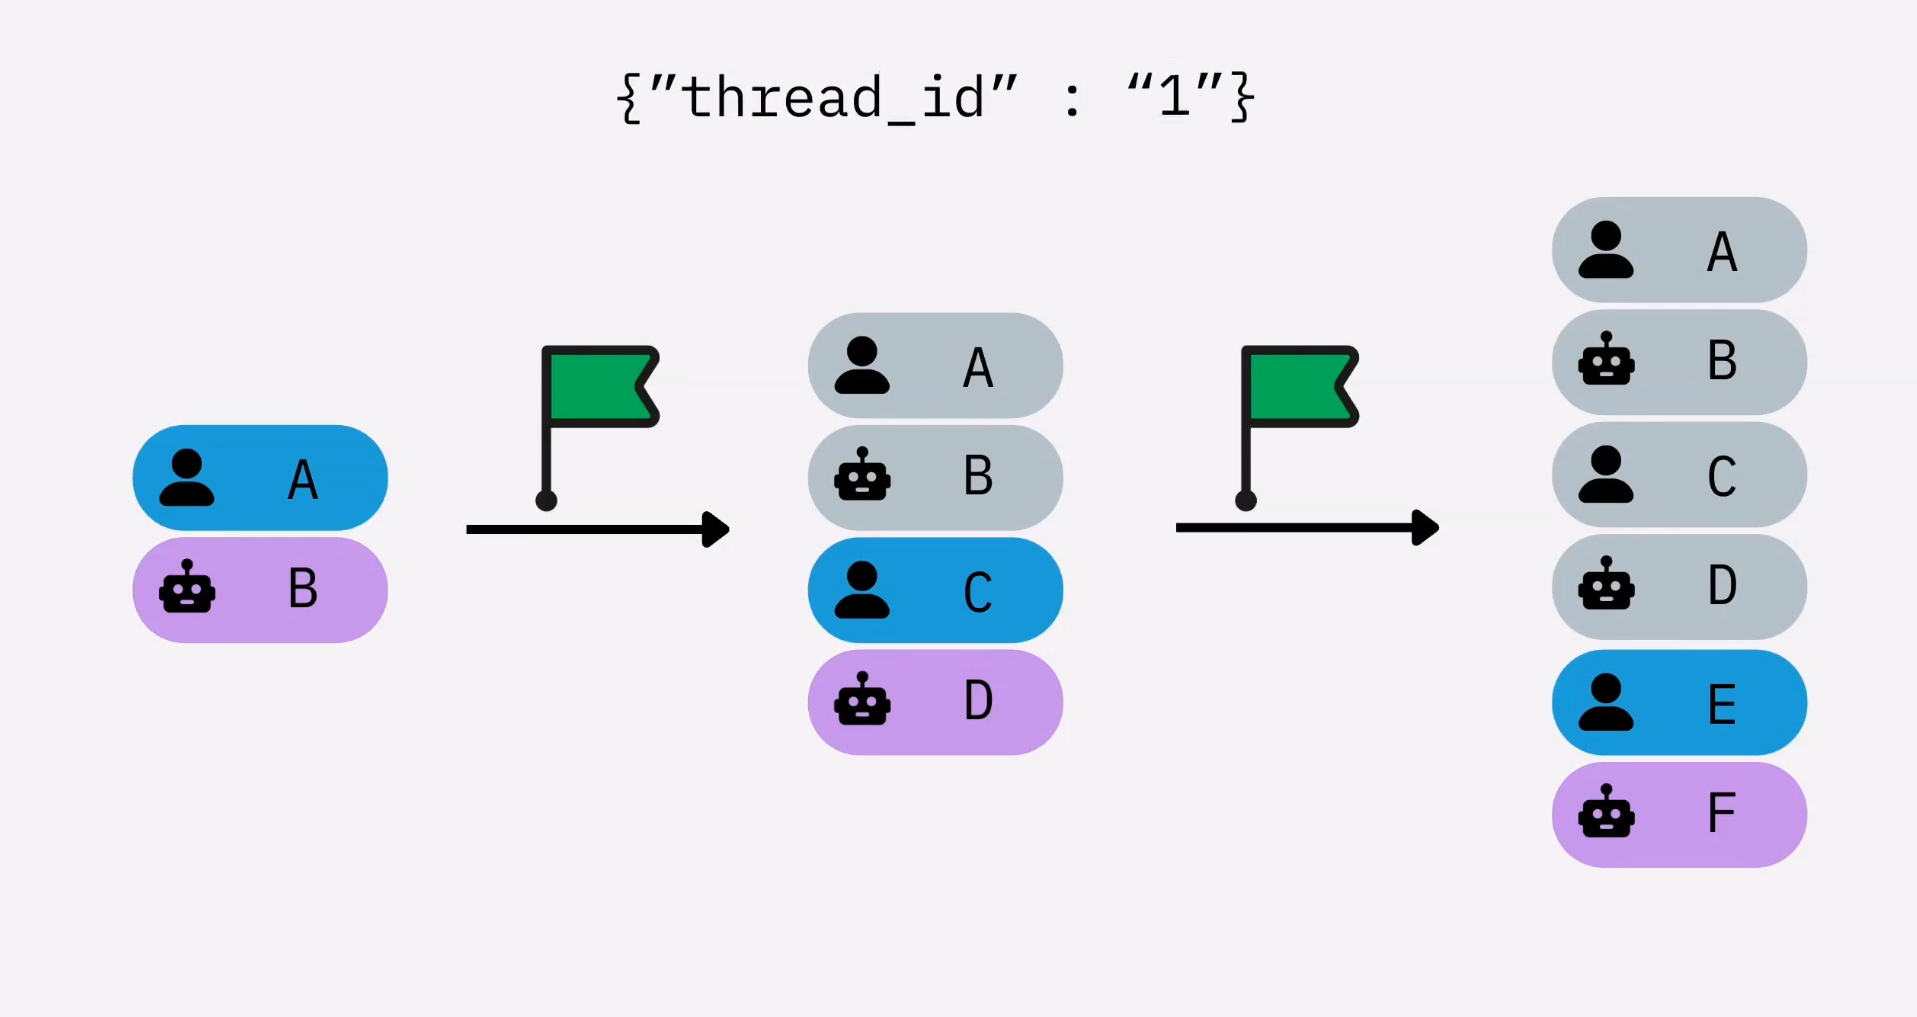

In [32]:
from langchain.messages import AIMessage

response = agent.invoke(
    {"messages": [HumanMessage(content="My name is Kamran. What is your name?"),
    AIMessage(content="Hello Kamran! I am Gemini"),
    HumanMessage(content="What is my name?")]}
)

pprint(response)

{'messages': [HumanMessage(content='My name is Kamran. What is your name?', additional_kwargs={}, response_metadata={}, id='ab453d3a-b1d3-4442-8032-6a985351ba00'),
              AIMessage(content='Hello Kamran! I am Gemini', additional_kwargs={}, response_metadata={}, id='46b966e4-06fe-437b-ae6c-99c594ce355d', tool_calls=[], invalid_tool_calls=[]),
              HumanMessage(content='What is my name?', additional_kwargs={}, response_metadata={}, id='7d019206-de0e-4f2e-ae5a-716271729ec8'),
              AIMessage(content=[{'type': 'text', 'text': 'Your name is Kamran!', 'extras': {'signature': 'EogFCoUFAWkUfROnhEsr8weoJEP+nfniH0JJ1112FXJFDwGZOrOWI6ncLyV5g9ytyMagO5EM68Ks7AWMyXMvXzM9OAn8s3deDcVYRIR9NhQzLs4zKB7NAt927aXu4wMX/qDBXV9as/g7yGZNRa0ai4vvXrf/j2U1fS5nQDyd6h+ruDzgtL4jqctRAHJptMkdcUGQVbs+nrLKvdGGFiA+PmVGQ/bMKwNQPPWICkHSUbZDrf/ypXKJPFGoKe3vZuWc81xDpftCSI/bG6pqZnhilfX7As1K1UJhfhb6KKXTo4k7QGcdSSGB4e57Gviy5Stc5g6CXLAhNtZQTOCzsykTy5EuAjtOWXb11I/FX5KTgFuQaNBQE7Zcqxh17qBpdj0oUOkNNHR9qYpLmDs

### 7. Streaming Output

In [34]:
for token, metadata in agent.stream(
    {"messages": [HumanMessage(content="Tell me all about capital city of Pakistan")]},
    stream_mode="messages"
):

    
    if token.content:  # Check if there's actual content
        print(token.content[-1]['text'], end="", flush=True)  # Print token

**Islamabad** is the purpose-built capital city of Pakistan. Renowned for its high standards of living, abundant greenery, safety, and modern architecture, it stands in stark contrast to many of the country's older, more chaotic historic cities. 

Here is a comprehensive overview of everything you need to know about Islamabad.

---

### 1. History and Origin
* **The Shift from Karachi:** When Pakistan gained independence in 1947, the coastal southern city of Karachi was chosen as the capital. However, President Ayub Khan wanted a capital that was centrally located, further away from potential naval attacks, easier to defend, and free from the commercial influences of Karachi.
* **The Master Plan:** In 1959, the site was chosen on the Pothohar Plateau at the foot of the Margalla Hills. The city was designed by the famous Greek architect and urban planner **Constantinos Apostolos Doxiadis**.
* **Naming and Inauguration:** The name *Islamabad* ("City of Islam") was chosen. Construction be

### 8. System Prompts

In [37]:
question = HumanMessage(content="What's the capital of the moon?")

response = agent.invoke(
    {"messages": [question]}
)

print(response['messages'][1].content[-1]['text'])

Technically, **the Moon does not have a capital city**. 

Because the Moon is not a country or a sovereign state, it has no government and no official capital. Under the **1967 Outer Space Treaty** (signed by over 110 countries), no nation can claim ownership of the Moon—it is considered the "common heritage of humankind."

However, depending on how you look at the question, there are a few fun ways to answer:

* **The Historical "Capital":** If any place on the Moon holds the most cultural significance to Earth, it would be **Tranquility Base** (*Statio Tranquillitatis*), the location in the Sea of Tranquility where Neil Armstrong and Buzz Aldrin first landed in 1969. 
* **The Sci-Fi "Capitals":** In science fiction, authors and creators often give the Moon a capital city. Common ones include:
  * **Tycho City** (featured in *Star Trek* and *The Expanse*)
  * **Luna City** (found in classic sci-fi by authors like Robert A. Heinlein)
  * **Artemis** (the lunar city in Andy Weir’s novel

In [ ]:
system_prompt = "You are a science fiction writer, create a capital city at the users request."

sci_agent = create_agent(
    model="google_genai:gemini-2.5-flash",
    system_prompt=system_prompt
)

response = sci_agent.invoke(
    {"messages": [question]}
)

print(response['messages'][-1].content)

Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.


Ah, an excellent question, one that delves into the future of human expansion!

The capital of the Moon, in the era of lunar colonization, is widely considered to be **Selenis**.

**Selenis** is not a single city in the traditional sense, but rather a sprawling, interconnected network of habitats, research facilities, and astroparks, predominantly built within and around a series of ancient, interconnected craters on the western edge of the **Mare Tranquillitatis** (Sea of Tranquility).

**Here's a glimpse of Selenis:**

*   **Architectural Marvel:** It's a breathtaking blend of shimmering, multi-layered geodesic domes that house verdant biospheres and public spaces, seamlessly merging with vast, subterranean complexes carved deep into the lunar regolith. These underground levels provide protection from radiation and micrometeoroids, housing most residential, industrial, and critical infrastructure.
*   **The Lunar Parliament:** At its heart lies the Grand Dome, a magnificent structure

_Apply the different prompting techniques to improve the quality of the responses from the LLM. The following are some of the prompting techniques that can be used:_
1. Few-shot prompting
2. Chain of thought prompting
3. Self-consistency prompting
4. Instruction prompting
5. Role prompting

### 9. ReAct Framework (Reasoning and Action)

![Screenshot 2026-09-18 143343.png](<attachment:Screenshot 2026-09-18 143343.png>)
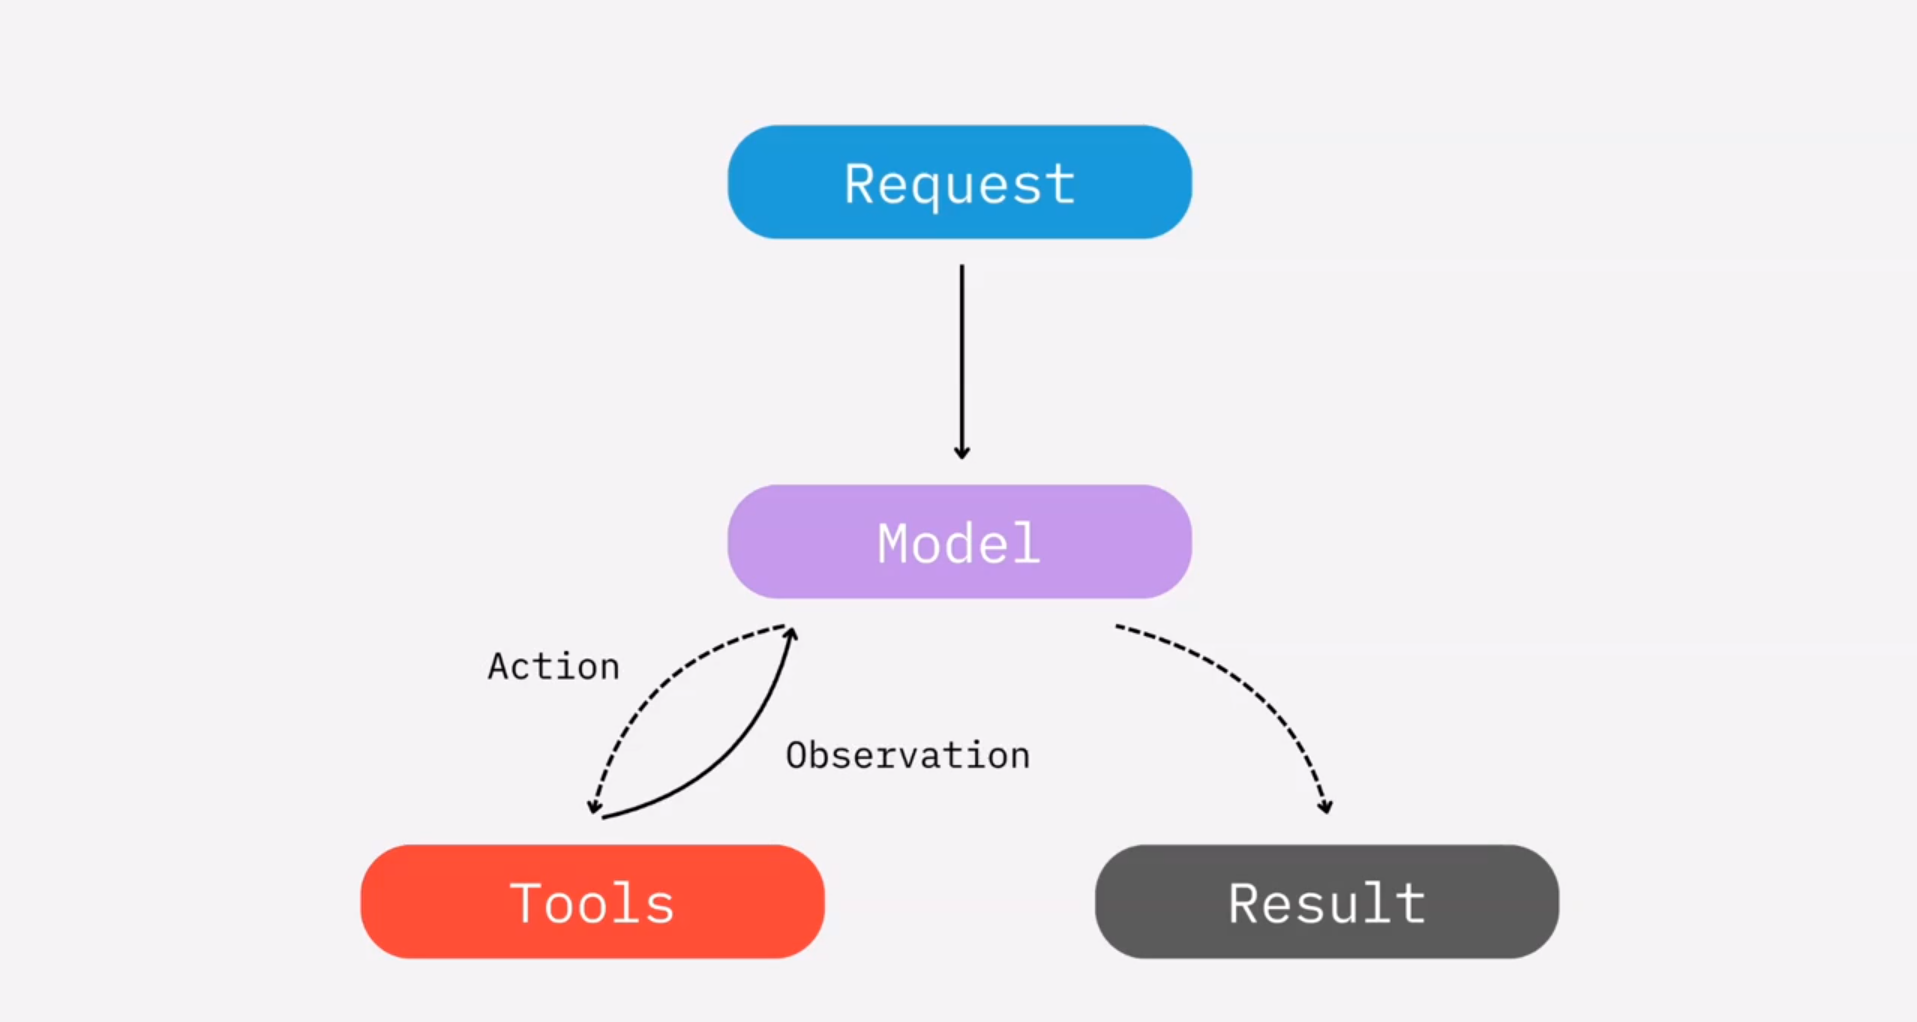

In [48]:
agent = create_agent(model="google_genai:gemini-3.6-flash")


result = agent.invoke({"messages": [{"role": "user", "content": "what is the current weather of Lahore?"}]})

# Extract the AI message (the last message in the list)
ai_message = result["messages"][-1]

# Extract the actual text from the first content block
response_text = ai_message.content[0]["text"]

print(response_text)

Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.


I do not have access to real-time weather information. 

To check the current weather in Lahore, please check a live weather website or app like Google Weather, Weather.com, or AccuWeather.


### 10. Tools

In [6]:
from langchain.agents import create_agent
from langchain.tools import tool
from dotenv import load_dotenv

load_dotenv()

# Defining Tools
@tool
def get_weather(city: str) -> str:
    '''Gives the current 
    weather in a given city.'''

    return f"The current weather in {city} is sunny."

agent = create_agent(model="google_genai:gemini-3.6-flash", tools=[get_weather])


result = agent.invoke({"messages": [{"role": "user", "content": "what is the current weather of Lahore?"}]})

# Extract the AI message (the last message in the list)
ai_message = result["messages"][-1]

# Extract the actual text from the first content block
response_text = ai_message.content[0]["text"]

print(response_text)

The current weather in Lahore is sunny.


### 11. Structured output

In [ ]:
from pydantic import BaseModel

# Define a Pydantic model for structured output
class Answer(BaseModel):
    summary: str
    confidence: float

agent = create_agent(model="google_genai:gemini-3.6-flash", tools=[get_weather], response_format=Answer)


result = agent.invoke({"messages": [{"role": "user", "content": "Summarize AI trends"}]})

print(result["structured_response"])

output = result["structured_response"]

# Print the structured output as a dictionary
print(output.model_dump())

summary='Key current AI trends include the rise of agentic workflows and autonomous systems, multimodal AI models integrating text, image, audio, and video, open-weight/open-source LLMs narrowing the gap with proprietary ones, increased focus on hardware efficiency, and growing regulatory compliance and AI safety frameworks globally.' confidence=0.9
{'summary': 'Key current AI trends include the rise of agentic workflows and autonomous systems, multimodal AI models integrating text, image, audio, and video, open-weight/open-source LLMs narrowing the gap with proprietary ones, increased focus on hardware efficiency, and growing regulatory compliance and AI safety frameworks globally.', 'confidence': 0.9}


### Assignment-1

##### Explore the Invocation and Streamimg in agents. Write a simple coding examples of these topics.

##### Create an Agent that can answer questions about the weather in a specific city. Explore the Free Weather API Platform to get the weather information. The agent should be able to take a city name as input and return the current weather conditions for that city.